Saving heart.csv to heart (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open heart-disease-dataset.zip, heart-disease-dataset.zip.zip or heart-disease-dataset.zip.ZIP.
Dat

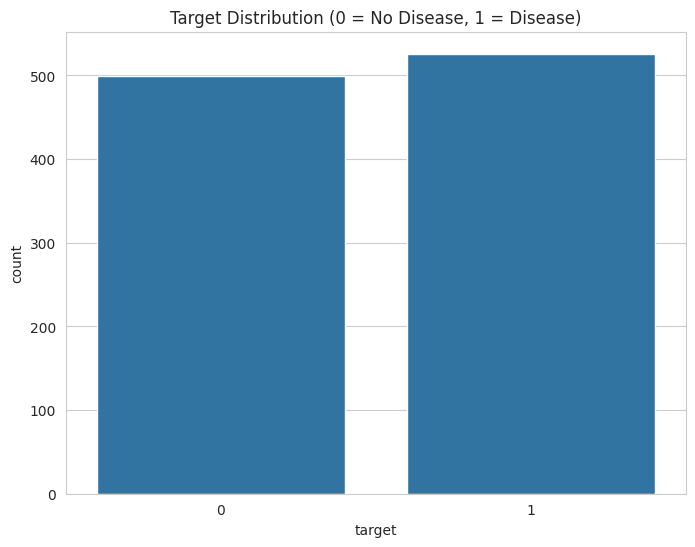

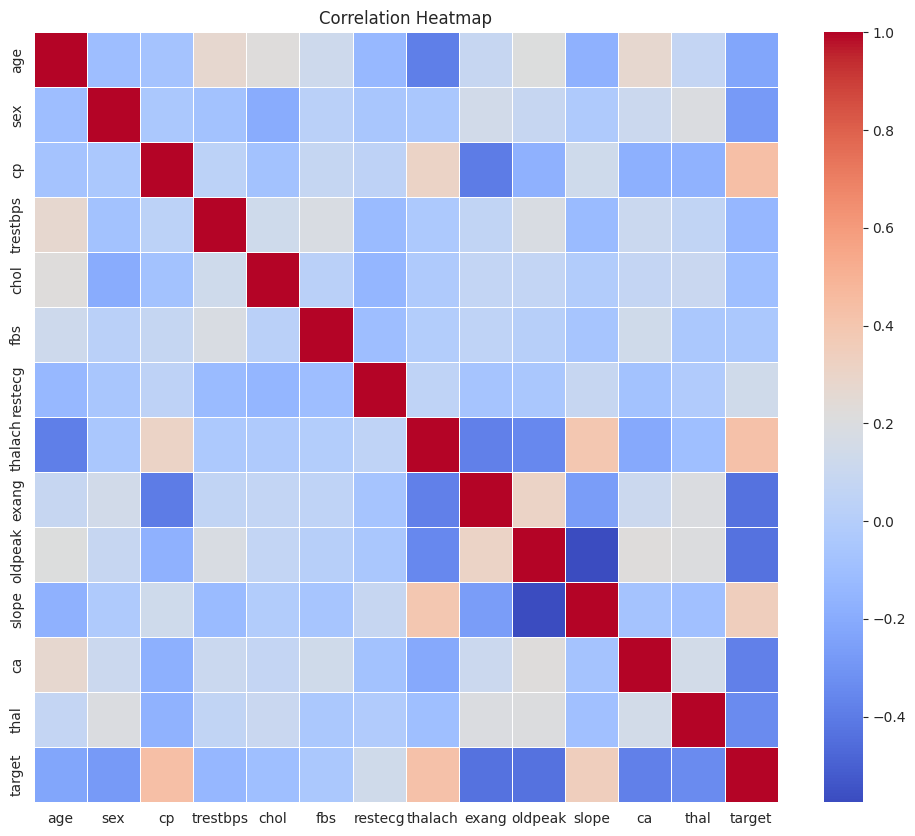

Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
# ==========================================================
# SUPPORT VECTOR MACHINE (SVM) CLASSIFICATION
# With Hyperparameter Tuning (GridSearchCV)
# Heart Disease Dataset - Kaggle
# ==========================================================

# -------------------------------
# STEP 1: Install & Setup Kaggle
# -------------------------------
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d johnsmith88/heart-disease-dataset
!unzip heart-disease-dataset.zip


# -------------------------------
# STEP 2: Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,6)


# -------------------------------
# STEP 3: Load Dataset
# -------------------------------
df = pd.read_csv("heart.csv")

print("Dataset Shape:", df.shape)
df.head()


# -------------------------------
# STEP 4: Data Exploration
# -------------------------------
print("\nMissing Values:\n", df.isnull().sum().sum())

# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# -------------------------------
# STEP 5: Split Features & Target
# -------------------------------
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------------------
# STEP 6: Feature Scaling
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# STEP 7: Hyperparameter Tuning
# -------------------------------
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


# -------------------------------
# STEP 8: Train Best Model
# -------------------------------
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)


# -------------------------------
# STEP 9: Model Evaluation
# -------------------------------
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -------------------------------
# STEP 10: ROC Curve
# -------------------------------
y_prob = best_svm.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("ROC AUC Score:", roc_auc)